# Gradient Descent as Search: Smiling Classifier on CelebA

Course project for COSC 3P96 (Machine Learning), Brock University.

Linear regression and logistic regression are written from scratch in NumPy and trained with gradient descent to predict the **Smiling** attribute from face images. The notebook looks at how the learning rate, the loss function and the input scaling affect convergence and accuracy.

**To run it:** put the CelebA files (`img_align_celeba/`, `list_attr_celeba.txt`, `list_eval_partition.txt`) in the same folder as this notebook. The dataset is not included in this repo. Needs `numpy`, `pandas`, `matplotlib` and `pillow`.

In [1]:
# NAME - Atharv Patel
# Project - Gradient Descent as Search for Facial Attribute Prediction
# Dataset - CelebA

## 1. Load the labels and splits

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

np.random.seed(42)

In [3]:
image_folder = "img_align_celeba"
attr_file = "list_attr_celeba.txt"
partition_file = "list_eval_partition.txt"

In [4]:
attr_df = pd.read_csv(attr_file, sep=r"\s+", skiprows=1, index_col=0)
attr_df = attr_df.reset_index().rename(columns={"index": "image_id"})

print("Fixed attribute file shape:", attr_df.shape)
attr_df.head()

Fixed attribute file shape: (202599, 41)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [5]:
print(attr_df[["image_id", "Smiling"]].head())
print(attr_df["Smiling"].value_counts())

     image_id  Smiling
0  000001.jpg        1
1  000002.jpg        1
2  000003.jpg       -1
3  000004.jpg       -1
4  000005.jpg       -1
Smiling
-1    104930
 1     97669
Name: count, dtype: int64


In [6]:
df = attr_df[["image_id", "Smiling"]].copy()
df["Smiling"] = df["Smiling"].replace({-1: 0, 1: 1})

print(df.head())
print(df["Smiling"].value_counts())

     image_id  Smiling
0  000001.jpg        1
1  000002.jpg        1
2  000003.jpg        0
3  000004.jpg        0
4  000005.jpg        0
Smiling
0    104930
1     97669
Name: count, dtype: int64


In [7]:
partition_df = pd.read_csv(
    partition_file,
    sep=r"\s+",
    header=None,
    names=["image_id", "partition"]
)

print(partition_df.shape)
print(partition_df.head())
print(partition_df["partition"].value_counts())

(202599, 2)
     image_id  partition
0  000001.jpg          0
1  000002.jpg          0
2  000003.jpg          0
3  000004.jpg          0
4  000005.jpg          0
partition
0    162770
2     19962
1     19867
Name: count, dtype: int64


In [8]:
df = pd.merge(df, partition_df, on="image_id")

print(df.shape)
print(df.head())
print(df["partition"].value_counts())

(202599, 3)
     image_id  Smiling  partition
0  000001.jpg        1          0
1  000002.jpg        1          0
2  000003.jpg        0          0
3  000004.jpg        0          0
4  000005.jpg        0          0
partition
0    162770
2     19962
1     19867
Name: count, dtype: int64


## 2. Balanced train, validation and test sets

In [9]:
# Create balanced train, validation and test sets

train_full = df[df["partition"] == 0].copy()
val_full   = df[df["partition"] == 1].copy()
test_full = df[df["partition"] == 2].copy()

def balanced_sample(split_df, n_per_class, seed=42):

    class_0 = split_df[split_df["Smiling"] == 0]
    class_1 = split_df[split_df["Smiling"] == 1]

    if len(class_0) < n_per_class or len(class_1) < n_per_class:
        raise ValueError(
            f"Not enough samples for balanced sampling. "
            f"Class 0 has {len(class_0)}, class 1 has {len(class_1)}, "
            f"but {n_per_class} are required per class."
        )

    sample_0 = class_0.sample(n=n_per_class, random_state=seed)
    sample_1 = class_1.sample(n=n_per_class, random_state=seed)

    balanced_df = pd.concat([sample_0, sample_1], axis=0)
    balanced_df = balanced_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced_df

train_df = balanced_sample(train_full, 3500)
val_df   = balanced_sample(val_full, 750)
test_df = balanced_sample(test_full, 750)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain class counts:")
print(train_df["Smiling"].value_counts())

print("\nValidation class counts:")
print(val_df["Smiling"].value_counts())

print("\nTest class counts:")
print(test_df["Smiling"].value_counts())

print("\nTrain sample:")
print(train_df.head())

print("\nValidation sample:")
print(val_df.head())

print("\nTest sample:")
print(test_df.head())

Train shape: (7000, 3)
Validation shape: (1500, 3)
Test shape: (1500, 3)

Train class counts:
Smiling
1    3500
0    3500
Name: count, dtype: int64

Validation class counts:
Smiling
1    750
0    750
Name: count, dtype: int64

Test class counts:
Smiling
1    750
0    750
Name: count, dtype: int64

Train sample:
     image_id  Smiling  partition
0  000844.jpg        1          0
1  024609.jpg        0          0
2  066540.jpg        0          0
3  146664.jpg        0          0
4  160772.jpg        1          0

Validation sample:
     image_id  Smiling  partition
0  170630.jpg        1          1
1  166038.jpg        1          1
2  182548.jpg        0          1
3  165384.jpg        0          1
4  181432.jpg        0          1

Test sample:
     image_id  Smiling  partition
0  192166.jpg        1          2
1  201438.jpg        1          2
2  197146.jpg        0          2
3  187603.jpg        0          2
4  188388.jpg        0          2


## 3. Load the images (32x32 grayscale, flattened to 1024 features)

In [10]:
# Load images, convert them to grayscale and resize them

def load_images(dataframe, image_folder, size=(32, 32)):
    images = []
    labels = []

    for _, row in dataframe.iterrows():
        img_path = os.path.join(image_folder, row["image_id"])

        try:
            img = Image.open(img_path).convert("L")
            img = img.resize(size)
            img_array = np.array(img, dtype=np.float32) / 255.0
            img_array = img_array.flatten()

            images.append(img_array)
            labels.append(row["Smiling"])

        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    if len(images) == 0:
        raise ValueError("No images were loaded. Check image paths and folder name.")

    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    return X, y

In [11]:
# Load the images and labels for train, validation, and test sets

X_train, y_train = load_images(train_df, image_folder)
X_val, y_val = load_images(val_df, image_folder)
X_test, y_test = load_images(test_df, image_folder)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7000, 1024)
y_train shape: (7000,)
X_val shape: (1500, 1024)
y_val shape: (1500,)
X_test shape: (1500, 1024)
y_test shape: (1500,)


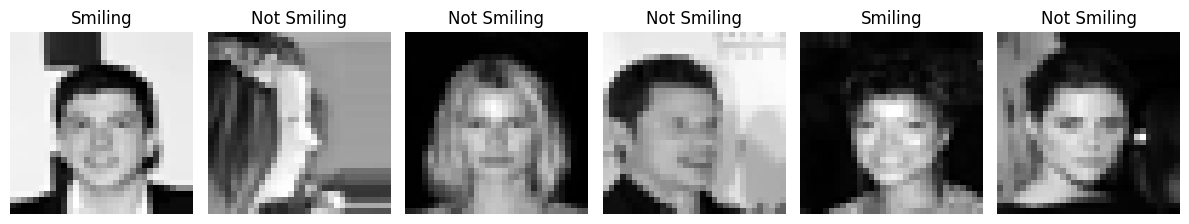

In [12]:
# Visualize some samples from the training set

def show_samples(X, y, num_samples=6):
    plt.figure(figsize=(12, 4))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(X[i].reshape(32, 32), cmap="gray")
        plt.title("Smiling" if y[i] == 1 else "Not Smiling")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(X_train, y_train)

## 4. Linear regression with gradient descent (MSE loss)

In [13]:
# Train a simple linear regression model using gradient descent

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def linear_predict(X, w, b):
    return X @ w + b

def train_linear_regression(X, y, lr=0.01, epochs=200):
    n_samples, n_features = X.shape
    w = np.zeros(n_features, dtype=np.float32)
    b = 0.0
    losses = []

    for epoch in range(epochs):
        y_pred = linear_predict(X, w, b)

        dw = (2 / n_samples) * (X.T @ (y_pred - y))
        db = (2 / n_samples) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

        loss = mse_loss(y, y_pred)
        losses.append(loss)

    return w, b, losses

First run with `lr=0.01`. On unstandardized pixels this diverges and the loss becomes `nan`.

Initial Linear Regression Loss: 0.5
Final Linear Regression Loss: nan


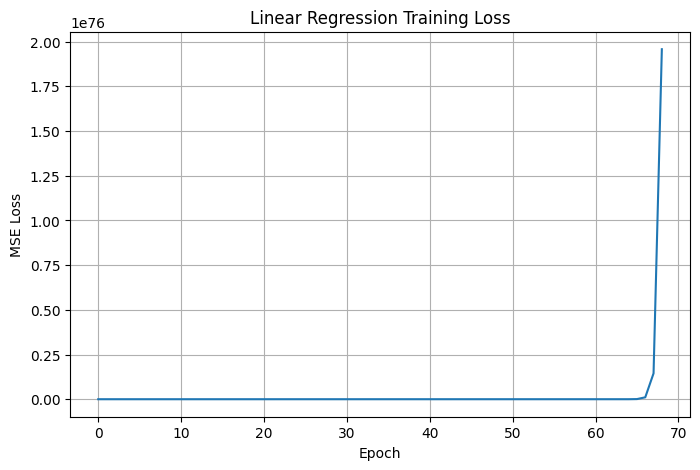

In [14]:
# Train the linear regression model and plot the training loss

w_lin, b_lin, lin_losses = train_linear_regression(X_train, y_train, lr=0.01, epochs=200)

print("Initial Linear Regression Loss:", lin_losses[0])
print("Final Linear Regression Loss:", lin_losses[-1])

plt.figure(figsize=(8, 5))
plt.plot(lin_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Linear Regression Training Loss")
plt.grid(True)

Second run with a much smaller learning rate (`lr=0.0001`), which converges.

Initial Linear Regression Loss: 0.5
Final Linear Regression Loss: 0.25120516453322955


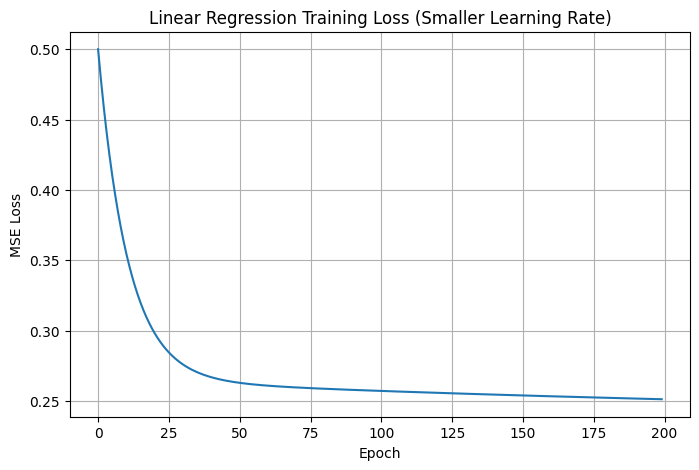

In [15]:
# Train the linear regression model with a smaller learning rate and plot the training loss

w_lin, b_lin, lin_losses = train_linear_regression(X_train, y_train, lr=0.0001, epochs=200)

print("Initial Linear Regression Loss:", lin_losses[0])
print("Final Linear Regression Loss:", lin_losses[-1])

plt.figure(figsize=(8, 5))
plt.plot(lin_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Linear Regression Training Loss (Smaller Learning Rate)")
plt.grid(True)

## 5. Logistic regression with gradient descent (cross-entropy loss)

In [16]:
# Train a logistic regression model using gradient descent

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-9
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def logistic_predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def train_logistic_regression(X, y, lr=0.01, epochs=200):
    n_samples, n_features = X.shape
    w = np.zeros(n_features, dtype=np.float32)
    b = 0.0
    losses = []

    for epoch in range(epochs):
        y_pred = logistic_predict_proba(X, w, b)

        dw = (X.T @ (y_pred - y)) / n_samples
        db = np.mean(y_pred - y)

        w -= lr * dw
        b -= lr * db

        loss = binary_cross_entropy(y, y_pred)
        losses.append(loss)

    return w, b, losses

Initial Logistic Regression Loss: 0.6931471824645996
Final Logistic Regression Loss: 0.6381431498405985


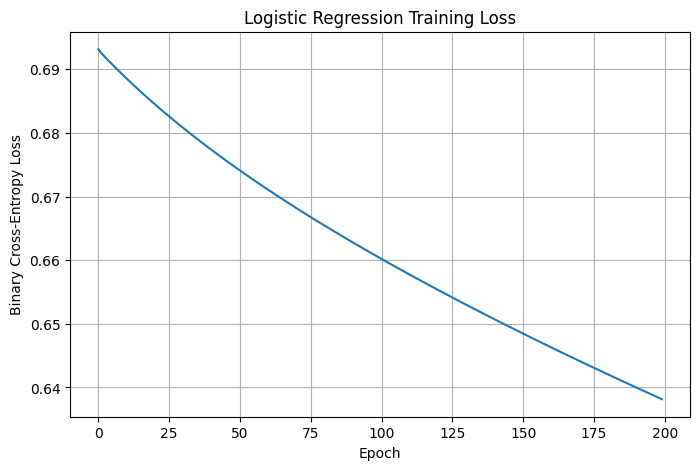

In [17]:
# Train the logistic regression model and plot the training loss

w_log, b_log, log_losses = train_logistic_regression(X_train, y_train, lr=0.01, epochs=200)

print("Initial Logistic Regression Loss:", log_losses[0])
print("Final Logistic Regression Loss:", log_losses[-1])

plt.figure(figsize=(8, 5))
plt.plot(log_losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Logistic Regression Training Loss")
plt.grid(True)

## 6. Evaluation

In [18]:
# Evaluate the models and compute classification metrics

def linear_predict_classes(X, w, b, threshold=0.5):
    y_pred = linear_predict(X, w, b)
    return (y_pred >= threshold).astype(int)

def logistic_predict_classes(X, w, b, threshold=0.5):
    y_pred_proba = logistic_predict_proba(X, w, b)
    return (y_pred_proba >= threshold).astype(int)

def confusion_matrix_values(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tn, fp, fn, tp

def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix_values(y_true, y_pred)

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

In [19]:
# Predict classes and compute metrics for both models on validation and test sets

lin_val_pred = linear_predict_classes(X_val, w_lin, b_lin)
lin_test_pred = linear_predict_classes(X_test, w_lin, b_lin)

log_val_pred = logistic_predict_classes(X_val, w_log, b_log)
log_test_pred = logistic_predict_classes(X_test, w_log, b_log)

lin_val_metrics = classification_metrics(y_val, lin_val_pred)
lin_test_metrics = classification_metrics(y_test, lin_test_pred)

log_val_metrics = classification_metrics(y_val, log_val_pred)
log_test_metrics = classification_metrics(y_test, log_test_pred)

print("Linear Regression Validation Metrics:")
print(lin_val_metrics)

print("\nLinear Regression Test Metrics:")
print(lin_test_metrics)

print("\nLogistic Regression Validation Metrics:")
print(log_val_metrics)

print("\nLogistic Regression Test Metrics:")
print(log_test_metrics)

Linear Regression Validation Metrics:
{'accuracy': np.float64(0.542), 'precision': np.float64(0.5518945634257795), 'recall': np.float64(0.44666666666607113), 'f1': np.float64(0.4937361822609044), 'tn': np.int64(478), 'fp': np.int64(272), 'fn': np.int64(415), 'tp': np.int64(335)}

Linear Regression Test Metrics:
{'accuracy': np.float64(0.5073333333333333), 'precision': np.float64(0.5092748735235931), 'recall': np.float64(0.40266666666612977), 'f1': np.float64(0.4497393889328201), 'tn': np.int64(459), 'fp': np.int64(291), 'fn': np.int64(448), 'tp': np.int64(302)}

Logistic Regression Validation Metrics:
{'accuracy': np.float64(0.6953333333333334), 'precision': np.float64(0.6701509872233796), 'recall': np.float64(0.7693333333323076), 'f1': np.float64(0.7163252633127818), 'tn': np.int64(466), 'fp': np.int64(284), 'fn': np.int64(173), 'tp': np.int64(577)}

Logistic Regression Test Metrics:
{'accuracy': np.float64(0.68), 'precision': np.float64(0.6580796252919695), 'recall': np.float64(0.749

In [20]:
# Create a comparison table of metrics for both models on validation and test sets

comparison_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Dataset": "Validation",
        "Accuracy": lin_val_metrics["accuracy"],
        "Precision": lin_val_metrics["precision"],
        "Recall": lin_val_metrics["recall"],
        "F1 Score": lin_val_metrics["f1"]
    },
    {
        "Model": "Linear Regression",
        "Dataset": "Test",
        "Accuracy": lin_test_metrics["accuracy"],
        "Precision": lin_test_metrics["precision"],
        "Recall": lin_test_metrics["recall"],
        "F1 Score": lin_test_metrics["f1"]
    },
    {
        "Model": "Logistic Regression",
        "Dataset": "Validation",
        "Accuracy": log_val_metrics["accuracy"],
        "Precision": log_val_metrics["precision"],
        "Recall": log_val_metrics["recall"],
        "F1 Score": log_val_metrics["f1"]
    },
    {
        "Model": "Logistic Regression",
        "Dataset": "Test",
        "Accuracy": log_test_metrics["accuracy"],
        "Precision": log_test_metrics["precision"],
        "Recall": log_test_metrics["recall"],
        "F1 Score": log_test_metrics["f1"]
    }
])

comparison_df = comparison_df.round(4)
print(comparison_df)

                 Model     Dataset  Accuracy  Precision  Recall  F1 Score
0    Linear Regression  Validation    0.5420     0.5519  0.4467    0.4937
1    Linear Regression        Test    0.5073     0.5093  0.4027    0.4497
2  Logistic Regression  Validation    0.6953     0.6702  0.7693    0.7163
3  Logistic Regression        Test    0.6800     0.6581  0.7493    0.7007


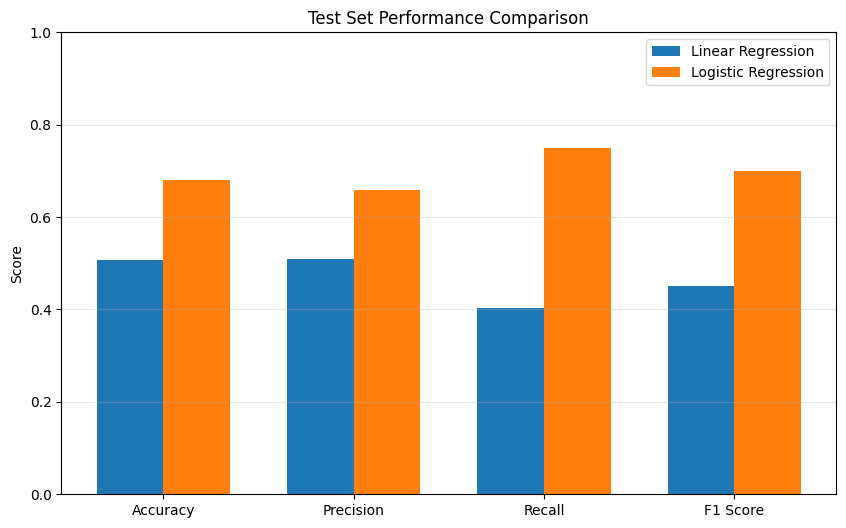

In [21]:
# Plot a bar chart comparing the metrics of both models on the test set

metrics_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
linear_test_values = [
    lin_test_metrics["accuracy"],
    lin_test_metrics["precision"],
    lin_test_metrics["recall"],
    lin_test_metrics["f1"]
]
logistic_test_values = [
    log_test_metrics["accuracy"],
    log_test_metrics["precision"],
    log_test_metrics["recall"],
    log_test_metrics["f1"]
]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, linear_test_values, width, label="Linear Regression")
plt.bar(x + width/2, logistic_test_values, width, label="Logistic Regression")

plt.xticks(x, metrics_names)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Test Set Performance Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

In [22]:
# Plot confusion matrices for both models on the test set

def plot_confusion_matrix(tn, fp, fn, tp, title):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Reds")
    plt.title(title)
    plt.colorbar()

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
    plt.yticks([0, 1], ["Actual 0", "Actual 1"])
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

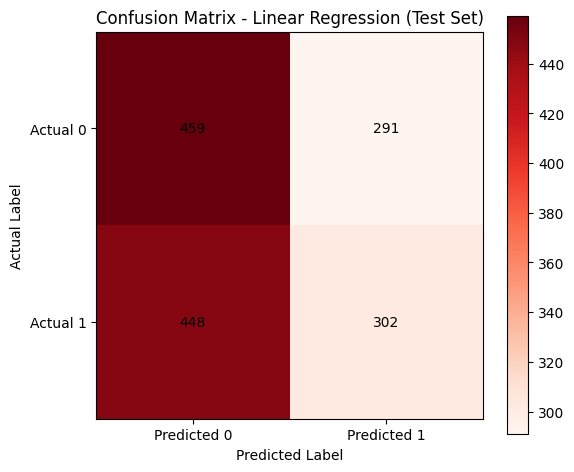

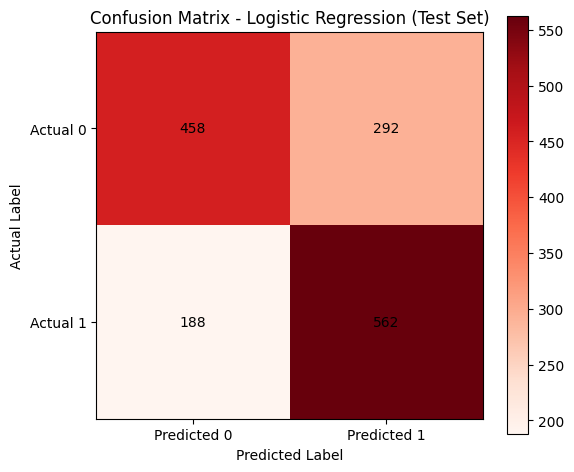

In [23]:
plot_confusion_matrix(
    lin_test_metrics["tn"], lin_test_metrics["fp"],
    lin_test_metrics["fn"], lin_test_metrics["tp"],
    "Confusion Matrix - Linear Regression (Test Set)"
)

plot_confusion_matrix(
    log_test_metrics["tn"], log_test_metrics["fp"],
    log_test_metrics["fn"], log_test_metrics["tp"],
    "Confusion Matrix - Logistic Regression (Test Set)"
)

## 7. Effect of the learning rate (logistic regression)

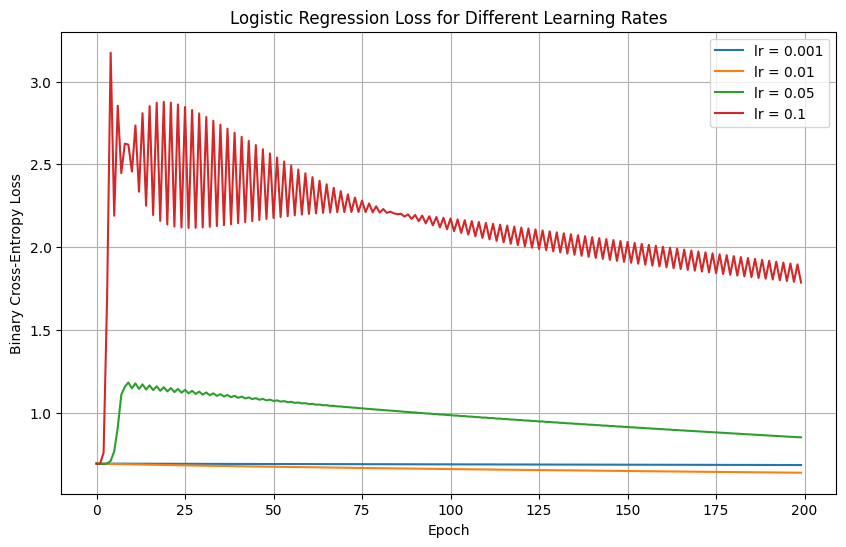

In [24]:
# Train logistic regression models with different learning rates and plot the losses

learning_rates = [0.001, 0.01, 0.05, 0.1]

logistic_lr_results = {}

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    w_temp, b_temp, losses_temp = train_logistic_regression(X_train, y_train, lr=lr, epochs=200)
    logistic_lr_results[lr] = {
        "w": w_temp,
        "b": b_temp,
        "losses": losses_temp
    }
    plt.plot(losses_temp, label=f"lr = {lr}")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Logistic Regression Loss for Different Learning Rates")
plt.legend()
plt.grid(True)

In [25]:
# Predict classes and compute metrics for each learning rate on validation and test sets

lr_comparison = []

for lr in learning_rates:
    w_temp = logistic_lr_results[lr]["w"]
    b_temp = logistic_lr_results[lr]["b"]

    val_pred = logistic_predict_classes(X_val, w_temp, b_temp)
    test_pred = logistic_predict_classes(X_test, w_temp, b_temp)

    val_metrics = classification_metrics(y_val, val_pred)
    test_metrics = classification_metrics(y_test, test_pred)

    lr_comparison.append({
        "Learning Rate": lr,
        "Final Train Loss": logistic_lr_results[lr]["losses"][-1],
        "Validation Accuracy": val_metrics["accuracy"],
        "Test Accuracy": test_metrics["accuracy"],
        "Test Precision": test_metrics["precision"],
        "Test Recall": test_metrics["recall"],
        "Test F1 Score": test_metrics["f1"]
    })

lr_comparison_df = pd.DataFrame(lr_comparison).round(4)
print(lr_comparison_df)

   Learning Rate  Final Train Loss  Validation Accuracy  Test Accuracy  \
0          0.001            0.6845               0.6000         0.5867   
1          0.010            0.6381               0.6953         0.6800   
2          0.050            0.8519               0.5627         0.5573   
3          0.100            1.7863               0.5493         0.5513   

   Test Precision  Test Recall  Test F1 Score  
0          0.5554       0.8693         0.6778  
1          0.6581       0.7493         0.7007  
2          0.9674       0.1187         0.2114  
3          0.9425       0.1093         0.1959  


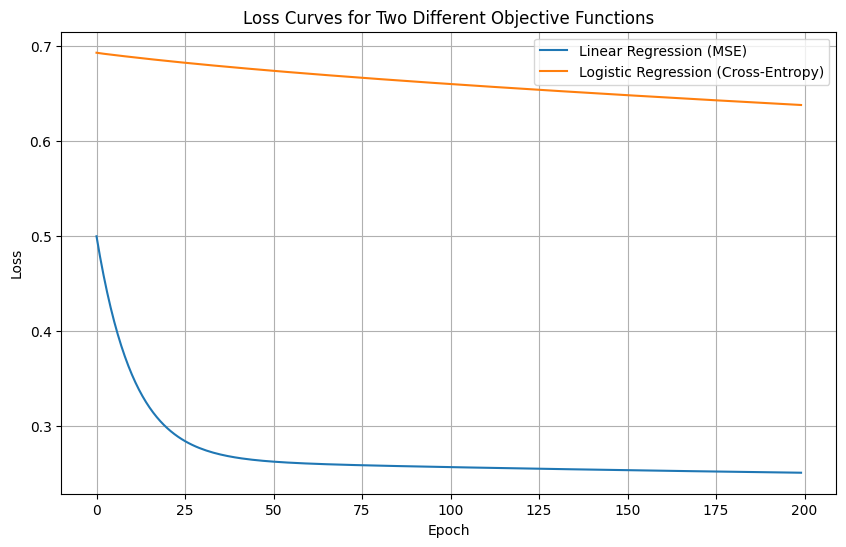

In [26]:
# Plot the training loss curves for linear regression and logistic regression

plt.figure(figsize=(10, 6))
plt.plot(lin_losses, label="Linear Regression (MSE)")
plt.plot(log_losses, label="Logistic Regression (Cross-Entropy)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves for Two Different Objective Functions")
plt.legend()
plt.grid(True)

## 8. Summary

In [27]:
print("# FINAL PROJECT SUMMARY")

print("\n1. Model Comparison & Hypothesis Space")
print(f"Linear Regression Test Accuracy: {lin_test_metrics['accuracy']:.4f}")
print(f"Logistic Regression Test Accuracy: {log_test_metrics['accuracy']:.4f}")
print("Logistic Regression outperformed Linear Regression because its outputs are")
print("constrained by the Sigmoid function to the [0, 1] range, making it more suitable")
print("for binary classification. Linear Regression produces continuous outputs and is")
print("less appropriate for modeling discrete class boundaries like smiling vs. not smiling.")

print("\n2. High-Dimensional Gradient Divergence")
print("In the initial Linear Regression run (lr=0.01), the model encountered 'NaN' loss values.")
print("With 1024 features (32x32 pixels), the dot product Xw can produce large magnitudes.")
print("Because the input is high-dimensional and the features were not standardized, the")
print("gradients likely became unstable at the higher learning rate, causing the optimization")
print("to overshoot instead of converge. Reducing the learning rate to 0.0001 stabilized training.")

print("\n3. Optimization Stability & Class Collapse")
print("In Logistic Regression, we observed class collapse at higher learning rates (lr=0.05, 0.1).")
print("The model predicted 'not smiling' for nearly all inputs. While this still produced")
print("moderate Accuracy, the Recall dropped sharply, showing that the optimization failed")
print("to find a useful decision boundary.")
print(f"The best balance was found at lr=0.01 (Test Accuracy: {log_test_metrics['accuracy']:.4f}, F1: {log_test_metrics['f1']:.4f}).")

print("\n4. Convergence Interpretation & Data Bottlenecks")
print("The Logistic Regression loss only decreased from 0.6931 to 0.6381 over 200 epochs.")
print("This modest improvement suggests underfitting. Because raw pixel values were used")
print("without stronger feature normalization or more expressive non-linear transformations,")
print("gradient descent was restricted to a linear hypothesis space that likely could not")
print("fully capture complex facial features such as smiling.")

print("\n5. Gradient Descent as Search Mechanism")
print("This project shows that Gradient Descent is not just an optimization algorithm, but")
print("a search strategy through a hypothesis space. The learning rate controls the step size")
print("of that search. If the step is too large, the search can overshoot the minimum; if it")
print("is too small, convergence can be very slow. Our results show that data preparation and")
print("hyperparameter tuning are as important as model choice.")

print("\n6. Final Conclusion & Future Scope")
print("We successfully implemented Linear and Logistic Regression from scratch, demonstrating")
print("that Logistic Regression is the better choice for this binary attribute prediction task.")
print("Future improvements could include feature standardization to improve optimization stability")
print("and more expressive non-linear models, such as deep neural networks, to better capture")
print("complex facial patterns.")

# FINAL PROJECT SUMMARY

1. Model Comparison & Hypothesis Space
Linear Regression Test Accuracy: 0.5073
Logistic Regression Test Accuracy: 0.6800
Logistic Regression outperformed Linear Regression because its outputs are
constrained by the Sigmoid function to the [0, 1] range, making it more suitable
for binary classification. Linear Regression produces continuous outputs and is
less appropriate for modeling discrete class boundaries like smiling vs. not smiling.

2. High-Dimensional Gradient Divergence
In the initial Linear Regression run (lr=0.01), the model encountered 'NaN' loss values.
With 1024 features (32x32 pixels), the dot product Xw can produce large magnitudes.
Because the input is high-dimensional and the features were not standardized, the
gradients likely became unstable at the higher learning rate, causing the optimization
to overshoot instead of converge. Reducing the learning rate to 0.0001 stabilized training.

3. Optimization Stability & Class Collapse
In Logistic R